# Notebook 04 — LoRA Fine-Tuning

Fine-tunes `Qwen2.5-3B-Instruct` with **4-bit QLoRA** (PEFT) on the Shakespeare translation task.

**Config**: r=16, alpha=32, NF4 4-bit quantization  
**Trainable params**: ~13M (~0.4% of 3B)  
**Expected VRAM**: ~6 GB (tuned for RTX 5070 Laptop 8 GB)  
**Expected time**: ~3-4 hours (3 epochs)

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # restrict to single GPU; prevents DataParallel with bitsandbytes 4-bit

import sys
import gc
import json
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('..').resolve()))
from src.model_utils import load_model_and_tokenizer, print_model_info
from src.data_utils import load_jsonl_as_hf_dataset
from src.training_utils import build_lora_config, build_lora_training_args

from trl import SFTTrainer

ROOT          = Path('..').resolve()
PROCESSED_DIR = ROOT / 'data' / 'processed'
HF_CACHE      = ROOT / 'data' / 'raw' / 'huggingface_cache'
OUTPUT_DIR    = ROOT / 'outputs' / 'exp1' / 'lora'
FIG_DIR       = ROOT / 'outputs' / 'exp1' / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ID = 'Qwen/Qwen2.5-3B-Instruct'
print('Setup complete.')
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


Setup complete.
GPU: NVIDIA RTX PRO 5000 Blackwell
VRAM: 50.8 GB


## 1. Load Datasets

In [2]:
train_dataset = load_jsonl_as_hf_dataset(PROCESSED_DIR / 'train.jsonl')
val_dataset   = load_jsonl_as_hf_dataset(PROCESSED_DIR / 'val.jsonl')

print('Train:', train_dataset)
print('Val:  ', val_dataset)

Train: Dataset({
    features: ['messages'],
    num_rows: 40084
})
Val:   Dataset({
    features: ['messages'],
    num_rows: 2234
})


## 2. Load Model with 4-bit QLoRA (8 GB VRAM)

In [3]:
# 4-bit NF4 quantization: weights ~3 GB instead of ~6 GB
# Required for RTX 5070 Laptop (8 GB VRAM)
model, tokenizer = load_model_and_tokenizer(
    MODEL_ID,
    quantization='4bit',
    attn_implementation='eager',  # change to 'flash_attention_2' if flash_attn installed
)
model.enable_input_require_grads()

print_model_info(model)

if torch.cuda.is_available():
    print(f'VRAM used after load: {torch.cuda.memory_allocated(0)/1e9:.2f} GB')

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

/home/prasingh/.conda/envs/advnlp/lib/python3.11/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Total parameters:     1,698,672,640
Trainable parameters: 311,406,592  (18.33%)
VRAM used after load: 2.06 GB


In [4]:
lora_config = build_lora_config(r=16, lora_alpha=32, lora_dropout=0.05)
print('LoRA config:')
print(f'  r:               {lora_config.r}')
print(f'  lora_alpha:      {lora_config.lora_alpha}')
print(f'  scale (a/r):     {lora_config.lora_alpha / lora_config.r:.1f}')
print(f'  target_modules:  {lora_config.target_modules}')

LoRA config:
  r:               16
  lora_alpha:      32
  scale (a/r):     2.0
  target_modules:  {'down_proj', 'gate_proj', 'q_proj', 'k_proj', 'o_proj', 'v_proj', 'up_proj'}


## 3. Training Configuration (8 GB tuned)

In [5]:
training_args = build_lora_training_args(
    output_dir=str(OUTPUT_DIR / 'checkpoints'),
    # 8 GB VRAM overrides
    per_device_train_batch_size=2,    # reduced from 4
    gradient_accumulation_steps=8,    # keeps effective batch = 16
    max_length=256,                   # reduced from 512 to save activation memory
    optim='paged_adamw_32bit',        # paged optimizer saves ~2 GB vs adamw_torch_fused
)

print('Key training arguments:')
print(f'  per_device_train_batch_size:  {training_args.per_device_train_batch_size}')
print(f'  gradient_accumulation_steps:  {training_args.gradient_accumulation_steps}')
print(f'  effective batch size:         {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}')
print(f'  learning_rate:                {training_args.learning_rate}')
print(f'  max_length:                   {training_args.max_length}')
print(f'  optimizer:                    {training_args.optim}')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Key training arguments:
  per_device_train_batch_size:  2
  gradient_accumulation_steps:  8
  effective batch size:         16
  learning_rate:                0.0002
  max_length:                   256
  optimizer:                    OptimizerNames.PAGED_ADAMW


## 4. Train

In [6]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    peft_config=lora_config,
)

# Check if complete, or find latest checkpoint to resume
_final = OUTPUT_DIR / 'final_adapter'
if _final.exists():
    print(f'Training already complete — found {_final}')
    print('Delete final_adapter/ to re-train.')
    train_result = None
else:
    _ckpts = sorted(
        (OUTPUT_DIR / 'checkpoints').glob('checkpoint-*'),
        key=lambda p: int(p.name.split('-')[-1])
    ) if (OUTPUT_DIR / 'checkpoints').exists() else []
    _resume = str(_ckpts[-1]) if _ckpts else None
    print(f'Resuming from: {_resume}' if _resume else 'Starting QLoRA training from scratch ...')
    train_result = trainer.train(resume_from_checkpoint=_resume)
    print(f'\nTraining complete.')
    print(f'  Train loss: {train_result.training_loss:.4f}')
    print(f'  Steps:      {train_result.global_step}')

Training already complete — found /home/prasingh/data/AdvNLP/outputs/exp1/lora/final_adapter
Delete final_adapter/ to re-train.


## 5. Save LoRA Adapter

In [7]:
adapter_path = str(OUTPUT_DIR / 'final_adapter')
trainer.save_model(adapter_path)
tokenizer.save_pretrained(adapter_path)
print(f'LoRA adapter saved to: {adapter_path}')

LoRA adapter saved to: /home/prasingh/data/AdvNLP/outputs/exp1/lora/final_adapter


In [8]:
log_path = ROOT / 'outputs' / 'exp1' / 'results' / 'lora_log_history.json'
log_path.parent.mkdir(parents=True, exist_ok=True)
if train_result is not None:
    with open(log_path, 'w') as f:
        json.dump(trainer.state.log_history, f)
    print(f'Log history saved to: {log_path}')
else:
    print('Training was skipped — log not updated.')
    if log_path.exists(): print(f'Existing log at: {log_path}')

Training was skipped — log not updated.
Existing log at: /home/prasingh/data/AdvNLP/outputs/exp1/results/lora_log_history.json


## 6. Training Loss Curve

Loaded 189 entries from lora_log_history.json.


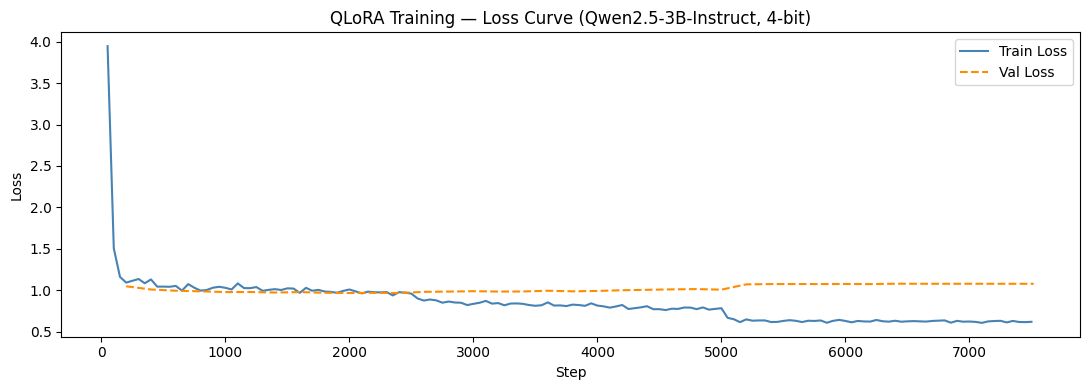

In [9]:
log_path = ROOT / 'outputs' / 'exp1' / 'results' / 'lora_log_history.json'
if log_path.exists():
    with open(log_path) as f:
        log_history = json.load(f)
    print(f'Loaded {len(log_history)} entries from {log_path.name}.')
else:
    log_history = trainer.state.log_history
    print('Using in-memory trainer log history.')
log_df = pd.DataFrame(log_history)
train_loss = log_df[log_df['loss'].notna()][['step', 'loss']]
eval_loss  = log_df[log_df['eval_loss'].notna()][['step', 'eval_loss']]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(train_loss['step'], train_loss['loss'], label='Train Loss', color='steelblue')
ax.plot(eval_loss['step'], eval_loss['eval_loss'], label='Val Loss', color='darkorange', linestyle='--')
ax.set_xlabel('Step'); ax.set_ylabel('Loss')
ax.set_title('QLoRA Training — Loss Curve (Qwen2.5-3B-Instruct, 4-bit)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'lora_loss_curve.png', dpi=150)
plt.show()

In [10]:
del model, trainer
gc.collect()
torch.cuda.empty_cache()
print('Memory freed.')

Memory freed.
